# EDA + Baseline — Previsão de Churn

Tech Challenge Fase 1 · Pós Tech ML Engineering (FIAP)

Este notebook cobre o entregável da Etapa 1: exploração de dados e baseline
com Regressão Logística. A lógica de limpeza usada aqui é a mesma do módulo
`churn_prediction.preprocessing`, reaproveitada no treino produtivo.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

In [2]:
df = pd.read_csv("../data/raw/Telco-Customer-Churn.csv")
df.shape

(7043, 21)

In [3]:
df.head(3)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

## Achados de qualidade de dados

- `TotalCharges` vem como string, com 11 linhas vazias — todas com `tenure=0`
  (clientes recém-chegados, sem ciclo de cobrança fechado ainda).
- `customerID` é único (sem duplicatas) — não é feature preditiva.
- Nenhuma linha duplicada.

In [5]:
coerced = pd.to_numeric(df["TotalCharges"], errors="coerce")
problematic = df[coerced.isna()]
print(f"Linhas problemáticas em TotalCharges: {len(problematic)}")
problematic[["customerID", "tenure", "MonthlyCharges", "TotalCharges", "Churn"]]

Linhas problemáticas em TotalCharges: 11


,customerID,tenure,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,52.55,,No
753,3115-CZMZD,0,20.25,,No
936,5709-LVOEQ,0,80.85,,No
1082,4367-NUYAO,0,25.75,,No
1340,1371-DWPAZ,0,56.05,,No
3331,7644-OMVMY,0,19.85,,No
3826,3213-VVOLG,0,25.35,,No
4380,2520-SGTTA,0,20.00,,No
5218,2923-ARZLG,0,19.70,,No
6670,4075-WKNIU,0,73.35,,No


In [6]:
print(df["Churn"].value_counts())
print(df["Churn"].value_counts(normalize=True).round(3))

Churn
No     5174
Yes    1869
Name: count, dtype: int64
Churn
No     0.735
Yes    0.265
Name: proportion, dtype: float64


## Limpeza (mesma lógica de `churn_prediction.preprocessing.clean_raw_dataframe`)

In [7]:
import sys
sys.path.insert(0, "../src")
from churn_prediction.preprocessing import clean_raw_dataframe, split_features_target

df_clean = clean_raw_dataframe(df)
df_clean["TotalCharges"].isna().sum()

np.int64(0)

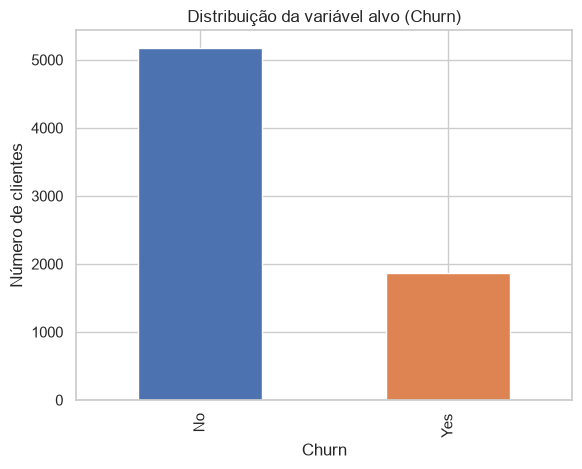

In [8]:
ax = df["Churn"].value_counts().plot(kind="bar", color=["#4C72B0", "#DD8452"])
ax.set_title("Distribuição da variável alvo (Churn)")
ax.set_ylabel("Número de clientes")
plt.show()

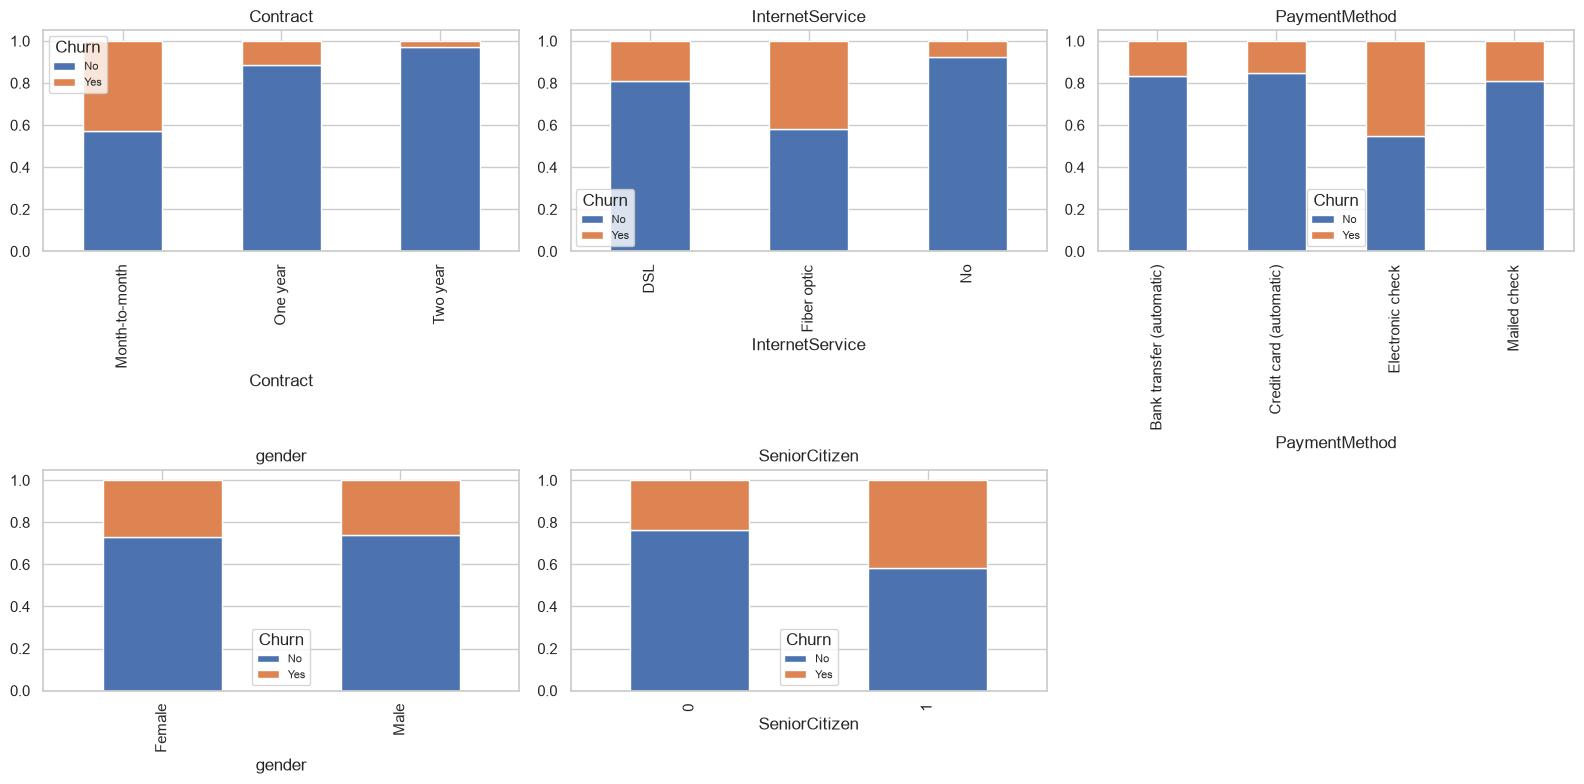

In [9]:
categorical_cols = ["Contract", "InternetService", "PaymentMethod", "gender", "SeniorCitizen"]

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, col in zip(axes.flatten(), categorical_cols):
    pd.crosstab(df[col], df["Churn"], normalize="index").plot(kind="bar", stacked=True, ax=ax)
    ax.set_title(col)
    ax.legend(title="Churn", fontsize=8)
fig.delaxes(axes.flatten()[-1])
plt.tight_layout()
plt.show()

## Baseline — Regressão Logística

Usamos o mesmo pipeline de `churn_prediction.train`, reproduzido aqui para
documentar e visualizar o resultado dentro do notebook (a versão que roda em
CI/produção fica em `src/churn_prediction/train.py`).

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, average_precision_score, f1_score, recall_score, classification_report
from churn_prediction.preprocessing import build_full_pipeline

X, y = split_features_target(df_clean)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

pipeline = build_full_pipeline(
    LogisticRegression(random_state=RANDOM_STATE, max_iter=1000, class_weight="balanced")
)
pipeline.fit(X_train, y_train)

y_pred = pipeline.predict(X_test)
y_proba = pipeline.predict_proba(X_test)[:, 1]

print("ROC-AUC:", roc_auc_score(y_test, y_proba))
print("PR-AUC:", average_precision_score(y_test, y_proba))
print("F1:", f1_score(y_test, y_pred))
print("Recall (Churn):", recall_score(y_test, y_pred))
print()
print(classification_report(y_test, y_pred))

ROC-AUC: 0.8414890593918727
PR-AUC: 0.6328716184396637
F1: 0.6136125654450262
Recall (Churn): 0.7834224598930482

              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1035
           1       0.50      0.78      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409



## Próximos passos (Etapa 2)

- Treinar Random Forest / ensemble e MLPClassifier com o mesmo split e seed.
- Comparar as 3 abordagens nas 4 métricas acima + análise de custo de negócio.
- Escolher o modelo campeão e salvá-lo em `models/`.